In [10]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_real_world_j10_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(990, 8)


In [16]:
import re

case_config = r'/home/zzj/projects/FTSAD/supp_files/real_config_table_4_ipynb.csv'

case_data = pd.read_csv(case_config)

def get_seg_type(row):
    min_seg_len = row['min_seg_len']
    max_seg_len = row['max_seg_len']
    seg_type = f"{min_seg_len}-{max_seg_len}"
    return seg_type

case_data['seg_type'] = case_data.apply(get_seg_type, axis=1)



data_new = pd.merge(data, case_data, how='left', on='case_name')

# 把所有case_name 为NIPS_TS_Creditcard的名字改成Creditcard
data_new['case_name'] = data_new['case_name'].replace('NIPS_TS_Creditcard', 'Creditcard')

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

print(data_new.head())
print(data_new.columns)

            case_name  ts_len  seg  max_seg_len  min_seg_len  avg_seg_len  \
0                 MSL   73729   36         1141           11   215.722222   
1  NIPS_TS_Creditcard  284807  465            5            1     1.058065   
2                SWAT  449919   35        35900          101  1560.600000   
3             SMD-1-1   28479    8          721            2   336.750000   
4             SMD-2-1   23694   13          452            8    90.000000   

    seg_type  
0    11-1141  
1        1-5  
2  101-35900  
3      2-721  
4      8-452  
(990, 14)
  case_name model_name  case_seed metric_name  mean_val   std_val  \
0       MSL    Model10         42      AUC-PR  0.057350  0.000155   
1       MSL    Model10         42     AUC-ROC  0.099658  0.002740   
2       MSL    Model10         42      Aff-F1  0.613145  0.012296   
3       MSL    Model10         42          F1  0.008382  0.001684   
4       MSL    Model10         42       F1-PA  0.687022  0.045130   

   mean_latency  std_l

In [ ]:
def plot_latency_distribution1(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg_type', 
                hue_order=seg_type_key_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    # 计算每个分组的平均值
    mean_values = df.groupby('metric_name')['mean_latency'].mean().reset_index()
    std_values = df.groupby('metric_name')['mean_latency'].std().reset_index()
    mean_values = mean_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    std_values = std_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))

    out_pth = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}_real.csv'
    # 转置
    saving_df = pd.merge(mean_values, std_values, on='metric_name', suffixes=('_mean', '_std'))
    saving_df.columns = ['Metric', 'Avg. Latency', 'Std. Latency']
    saving_df['Avg. Latency per point'] = saving_df['Avg. Latency'] / ts_len
    print(saving_df)
    saving_df.to_csv(out_pth, index=False)
    

    mean_values = mean_values.to_numpy()
    plt.plot(mean_values[:, 0], mean_values[:, 1], color='red', marker='o', markersize=2, label='Avg. Latency'
             , linestyle='--', linewidth=0.9,
            #  透明度
                alpha=0.5
             )
    # 在上方显示平均值
    x_positions = np.arange(len(metric_sort))  # 获取 x 轴的位置
    
        
    plt.legend(title='Segment Type')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}_real.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution1(data_new)  # Plot for ts_len = 100000
plot_latency_distribution1(data_new,10000)  # Plot for ts_len = 100000

[(4, '4 Segs (SMD-3-1)'), (8, '8 Segs (SMD-1-1)'), (13, '13 Segs (SMD-2-1)'), (35, '35 Segs (SWAT)'), (36, '36 Segs (MSL)'), (465, '465 Segs (Creditcard)')]
[4, 8, 13, 35, 36, 465]


[<matplotlib.patches.Rectangle object at 0x7dd2714a9250>, <matplotlib.patches.Rectangle object at 0x7dd274600e90>, <matplotlib.patches.Rectangle object at 0x7dd274a11490>, <matplotlib.patches.Rectangle object at 0x7dd2719a8e60>, <matplotlib.patches.Rectangle object at 0x7dd271c21b80>, <matplotlib.patches.Rectangle object at 0x7dd27154a720>] ['4', '8', '13', '35', '36', '465']


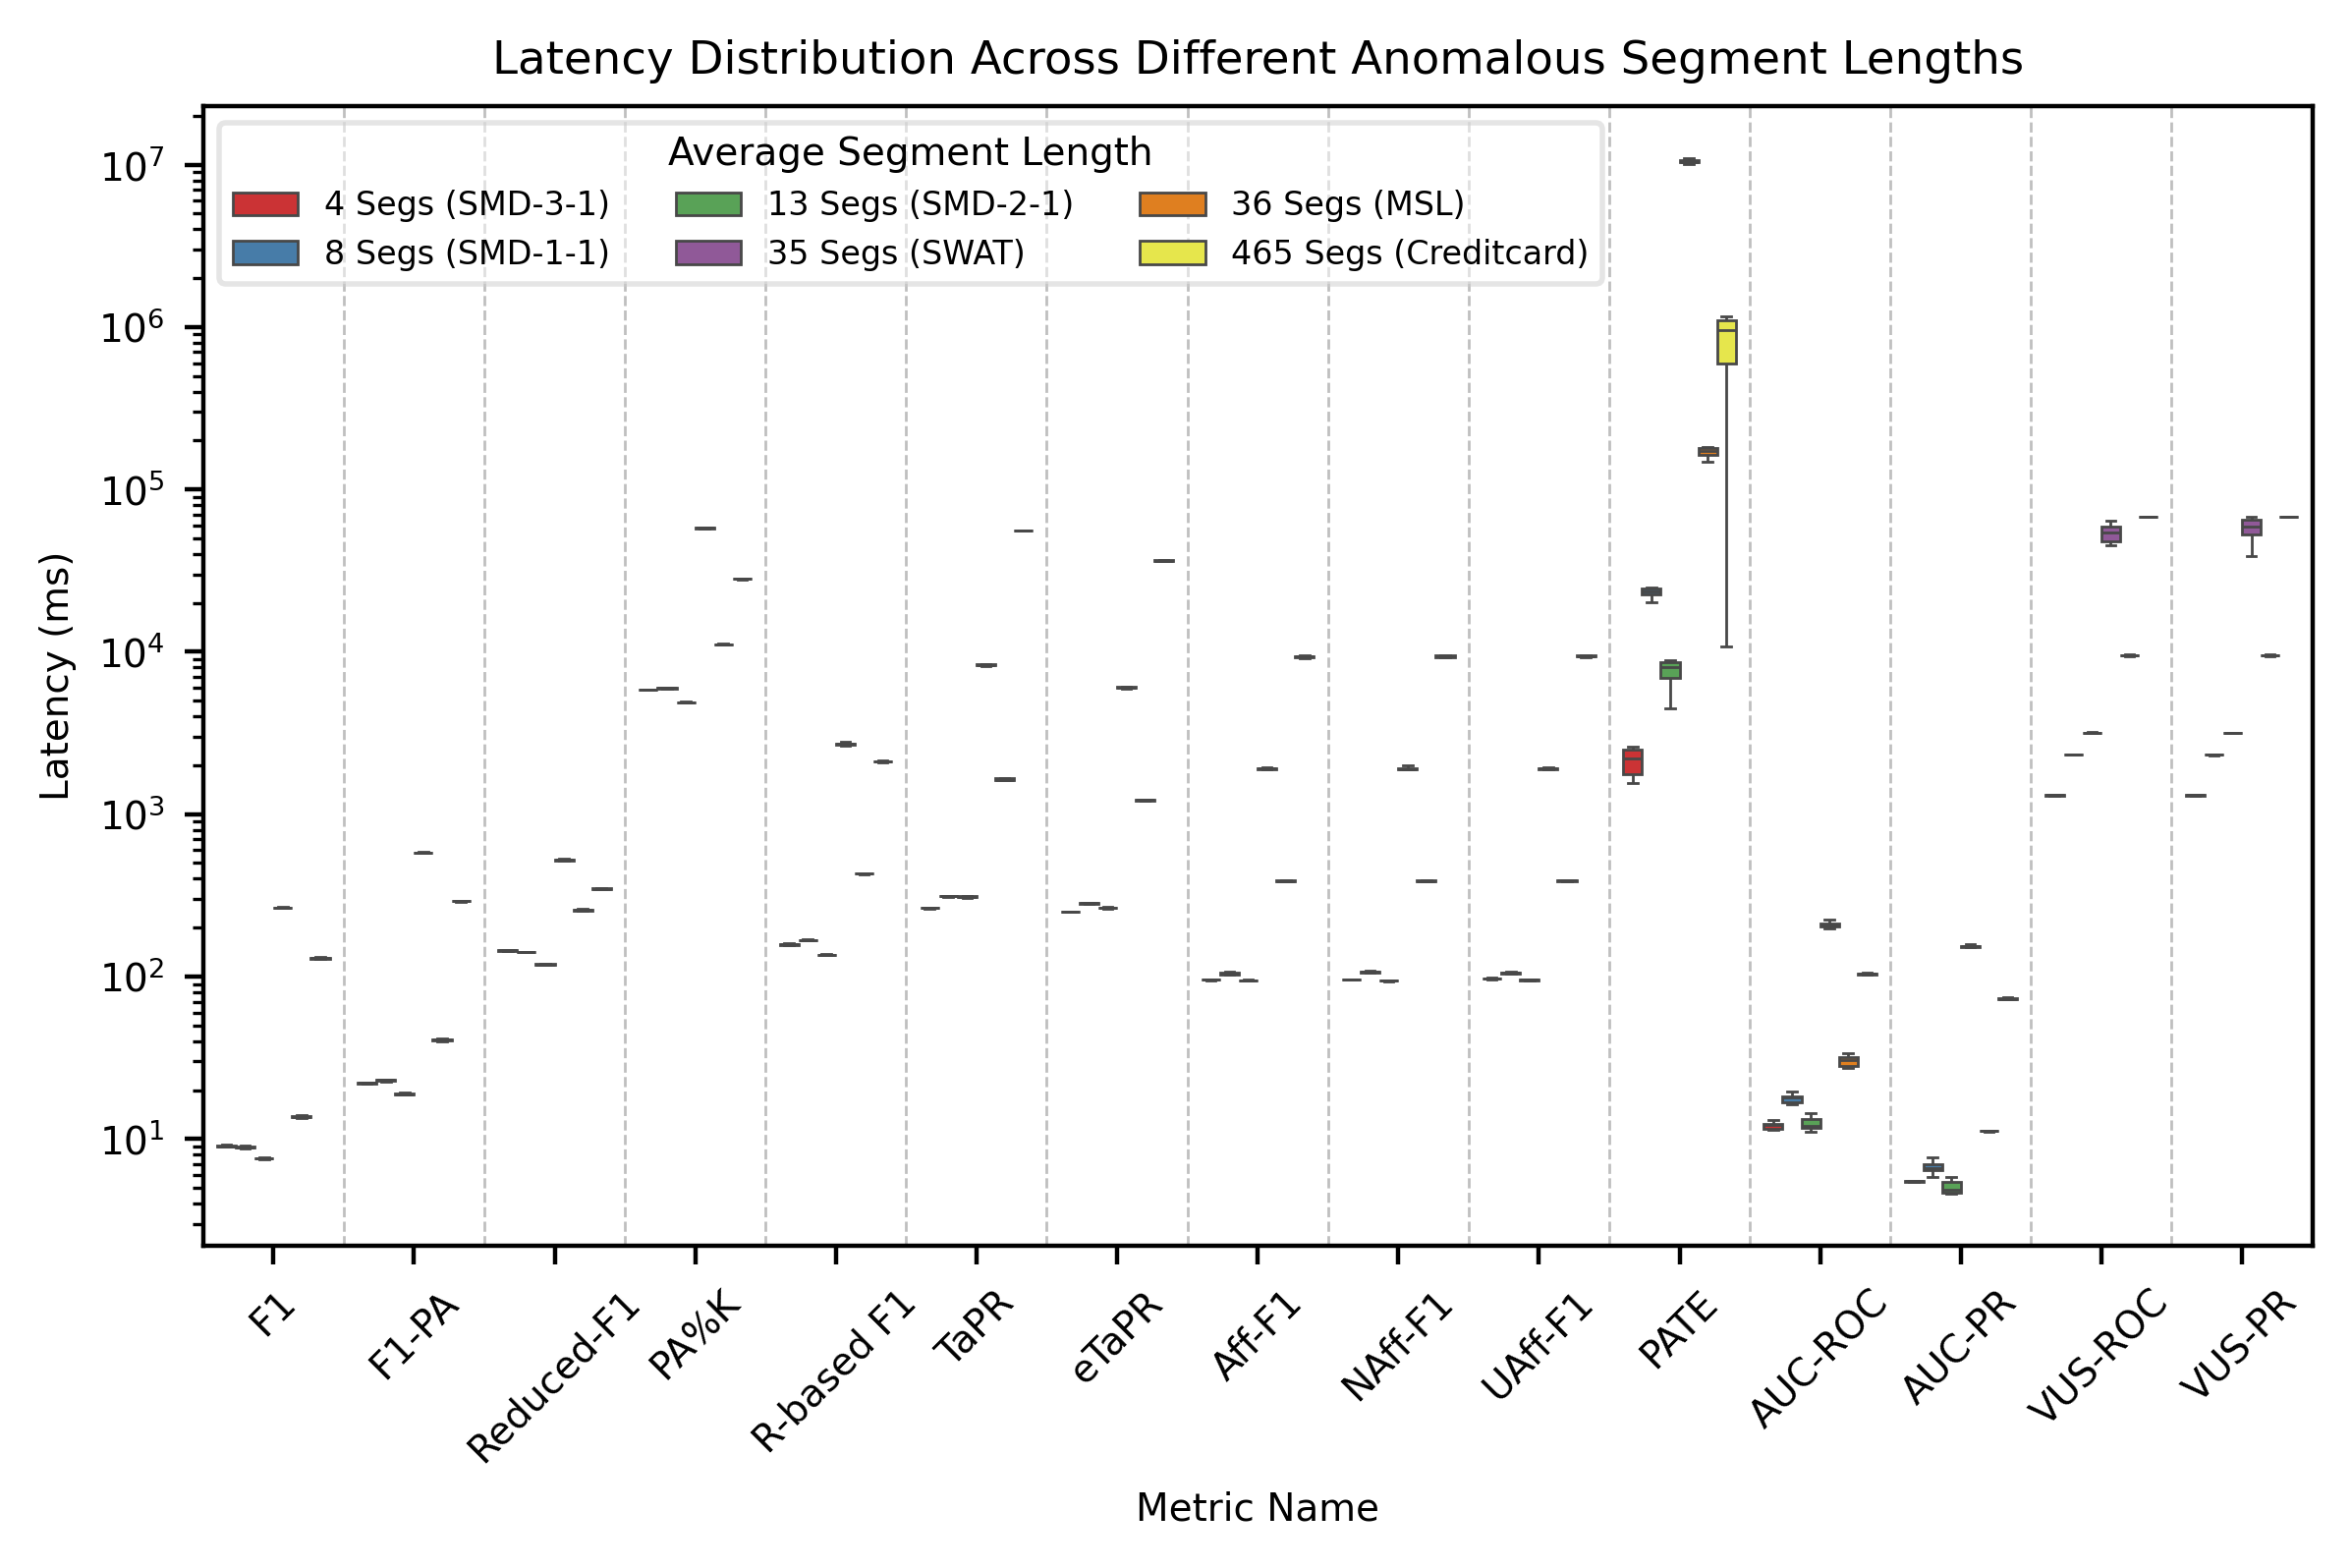

[(23694, '23694 (SMD-2-1)'), (28479, '28479 (SMD-1-1)'), (28700, '28700 (SMD-3-1)'), (73729, '73729 (MSL)'), (284807, '284807 (Creditcard)'), (449919, '449919 (SWAT)')]
[23694, 28479, 28700, 73729, 284807, 449919]
[<matplotlib.patches.Rectangle object at 0x7dd26a2b0740>, <matplotlib.patches.Rectangle object at 0x7dd26a11d4f0>, <matplotlib.patches.Rectangle object at 0x7dd269faa540>, <matplotlib.patches.Rectangle object at 0x7dd271d78950>, <matplotlib.patches.Rectangle object at 0x7dd271d7ae40>, <matplotlib.patches.Rectangle object at 0x7dd271d7bb90>] ['11-1141', '1-5', '2-721', '8-452', '21-131', '101-35900']


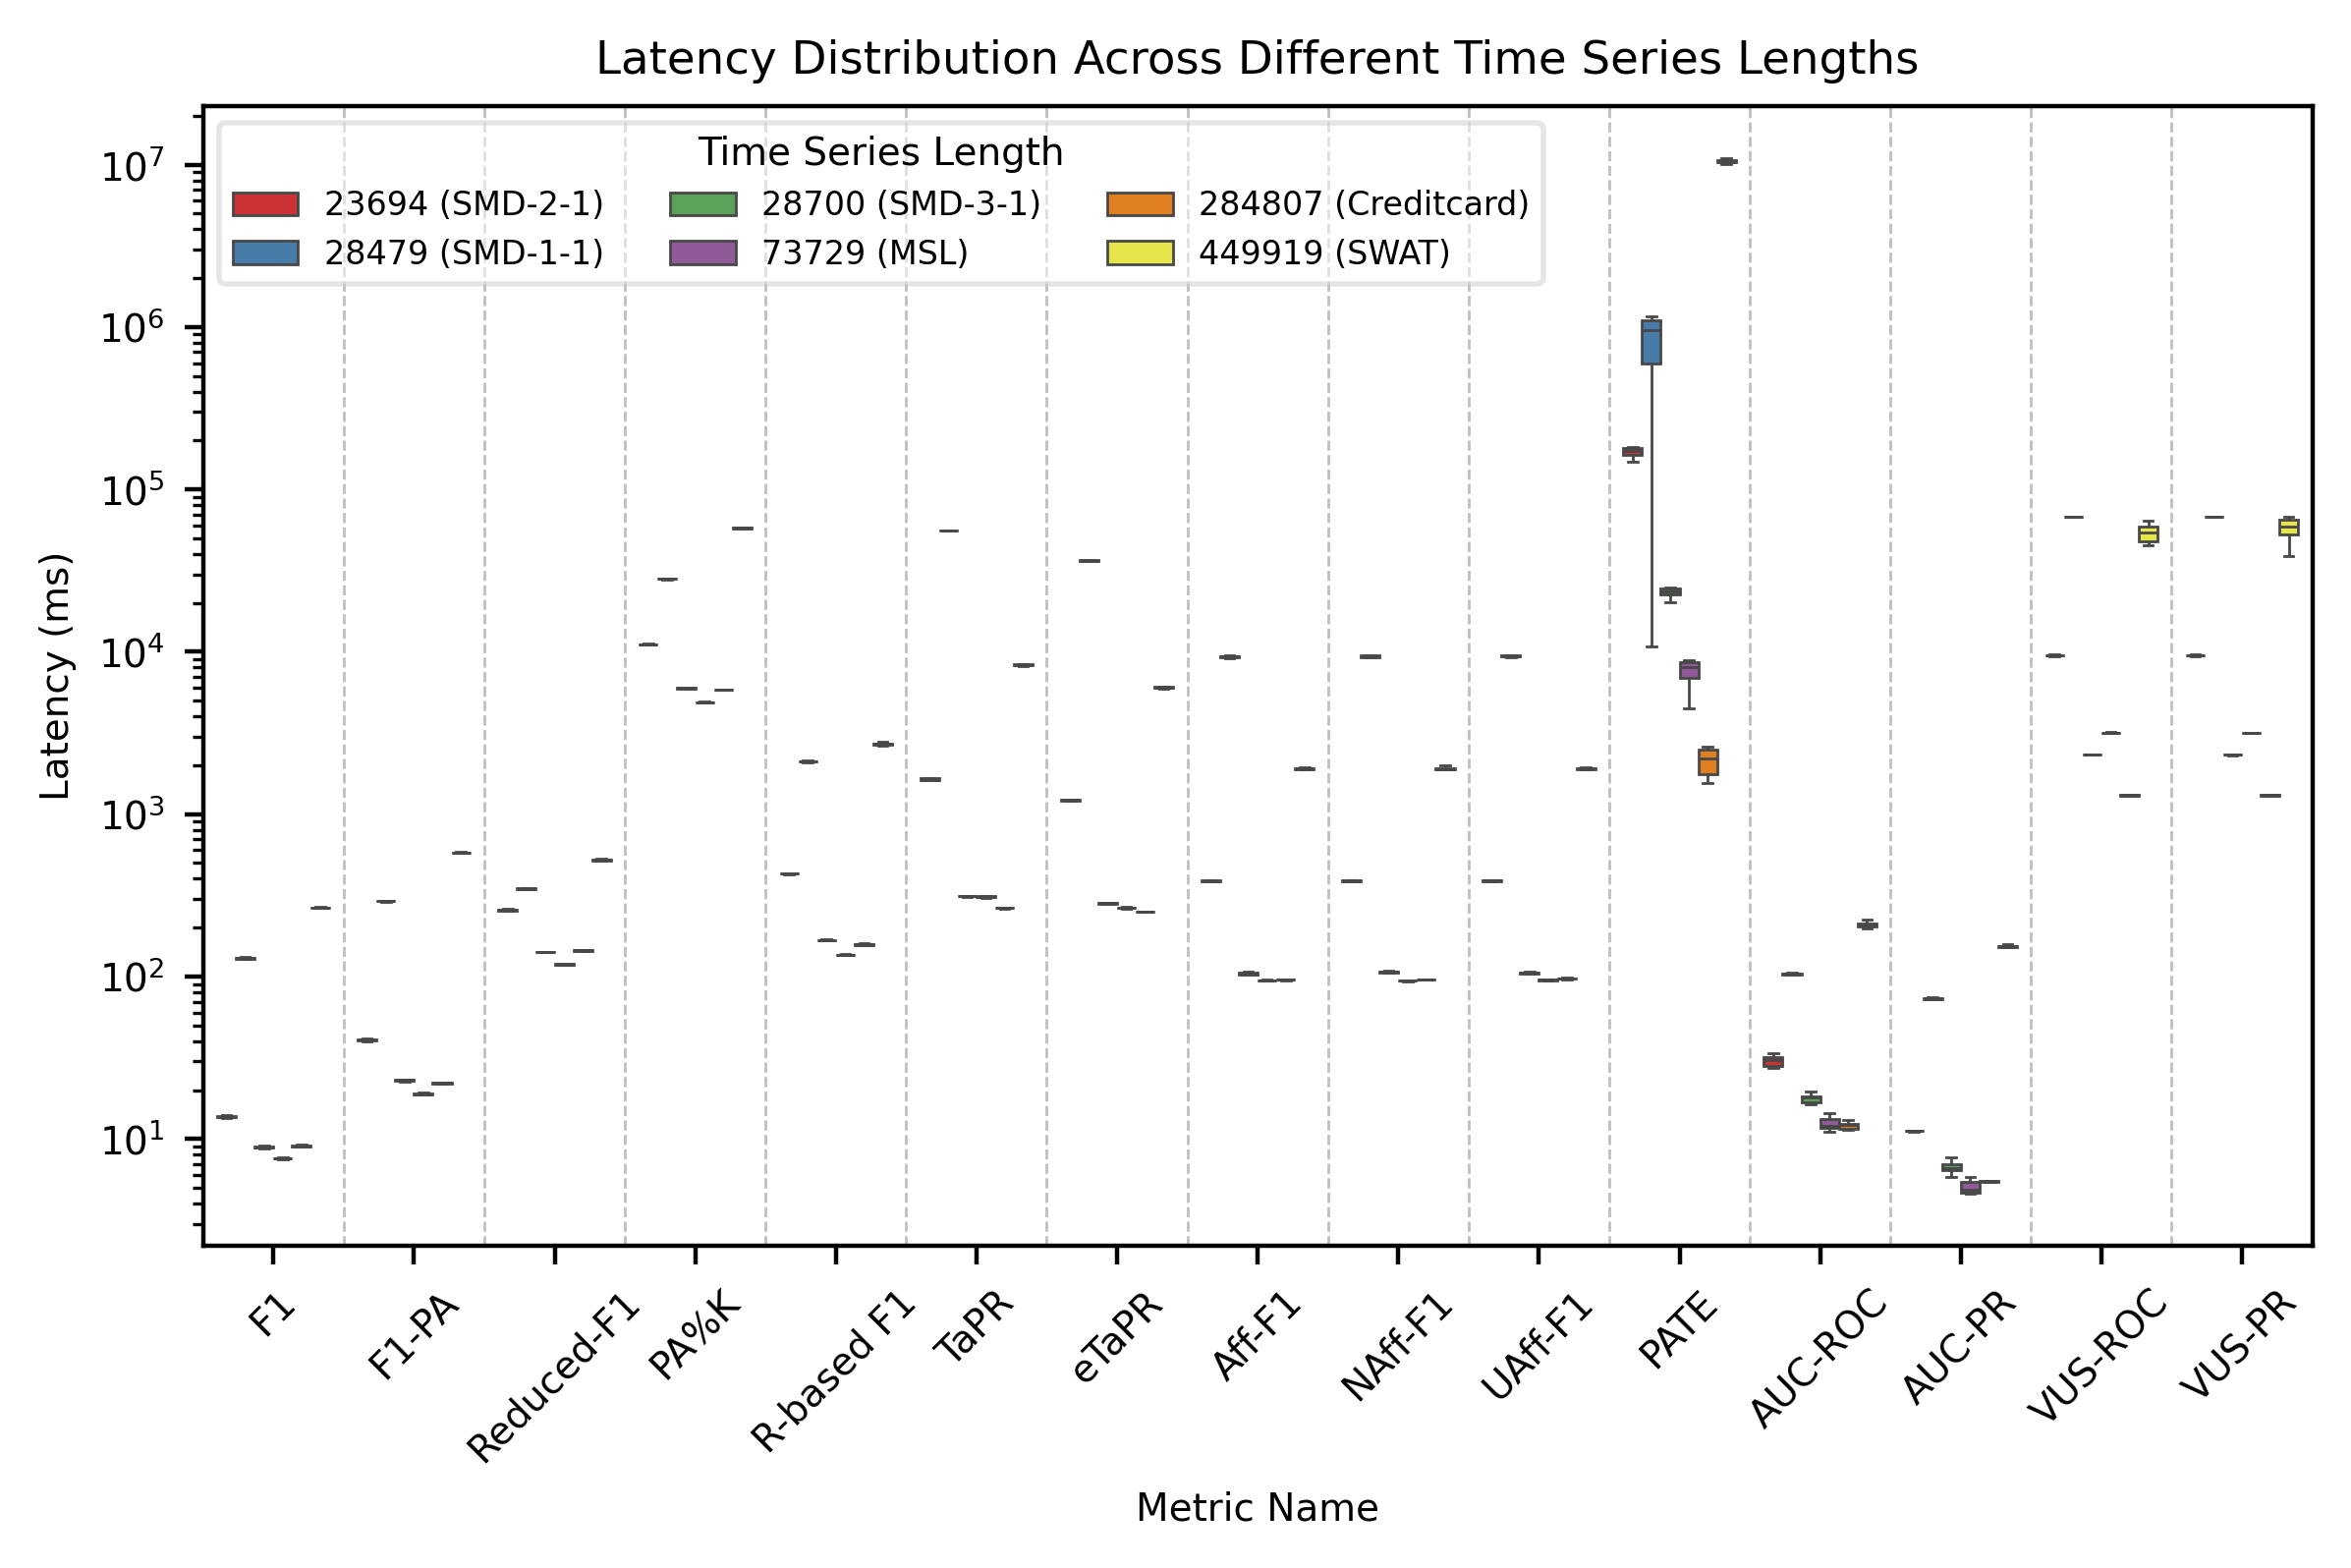

In [54]:
def plot_latency_distribution2(data_new, ver=1):
    df = data_new.copy()

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    seg_type = df['seg_type'].unique()
    seg_avg_len = df['avg_seg_len'].unique()
    data_name = df['case_name'].unique()
    ts_len = df['ts_len'].unique()

    order_list = []
    if ver==1:
        out_name ='seg_latency_real'
        for data_n, seg in zip(data_name, seg_list):
            order_list.append((seg, f'{seg} Segs ({data_n})'))
    elif ver==2:
        out_name = 'len_latency_real'
        for data_n, ts_len_ in zip(data_name, ts_len):
            # avg_len = round(avg_len, 2)
            order_list.append((ts_len_, f'{ts_len_} ({data_n})'))
            # order_list.append((avg_len, f'Seg Len: {avg_len:.2f} ({data_n})'))

    # print(seg_list, seg_type, data_name)
    order_list = sorted(order_list, key=lambda x: x[0])
    print(order_list)
    seg_list = [x[0] for x in order_list]
    print(seg_list)
    legend_list = [x[1] for x in order_list]

    if ver == 1:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                    order=metric_sort, 
                    hue='seg', 
                    hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1') 
    elif ver == 2:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                    order=metric_sort, 
                    hue='seg_type', 
                    # hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1') 
    
    # min_max_ratios = df.groupby(['metric_name', 'seg'])['mean_latency'].agg(['min', 'max']).reset_index()
    # min_max_ratios['ratio'] = min_max_ratios['max'] / min_max_ratios['min']
    # seg_list = df['seg'].unique()
    # seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort 
    # 获取当前图例句柄和标签
    handles, labels = plot1_handle.get_legend_handles_labels()
    print(handles, labels)

    # 设置新的图例标签
    legend_title = 'Average Segment Length' if ver == 1 else 'Time Series Length'
    plot1_handle.legend(handles, legend_list, title=legend_title, fontsize=6, loc='upper left', title_fontsize=7, framealpha=0.5,
                        ncol=3)
    # 计算每个 seg 类别的位置
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # plt.legend(title='Dataset')
    # 翻译：不同异常片段长度下的延迟分布
    if ver==1:
        plt.title(f'Latency Distribution Across Different Anomalous Segment Lengths')
    elif ver==2:
        plt.title(f'Latency Distribution Across Different Time Series Lengths')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/{out_name}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments
plot_latency_distribution2(data_new,ver=2)  # Plot for all segments


/tmp/ipykernel_3913586/3672871839.py:27: UserWarning: The palette list has more values (20) than needed (11), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df,


    metric_name model_name          mean           std
40           F1    Model70     73.021488    107.512979
39           F1    Model60     72.287395    106.101162
38           F1    Model50     77.227240    119.306249
37           F1    Model40     72.718782    106.256697
36           F1    Model30     72.606590    106.336826
..          ...        ...           ...           ...
139      VUS-PR    Model70  24782.246396  32201.807571
133      VUS-PR   Model100  24775.867997  32649.021257
134      VUS-PR    Model20  22037.623756  28673.482876
132      VUS-PR    Model10  23836.386753  30891.354794
135      VUS-PR    Model30  21796.444052  28388.797418

[165 rows x 4 columns]


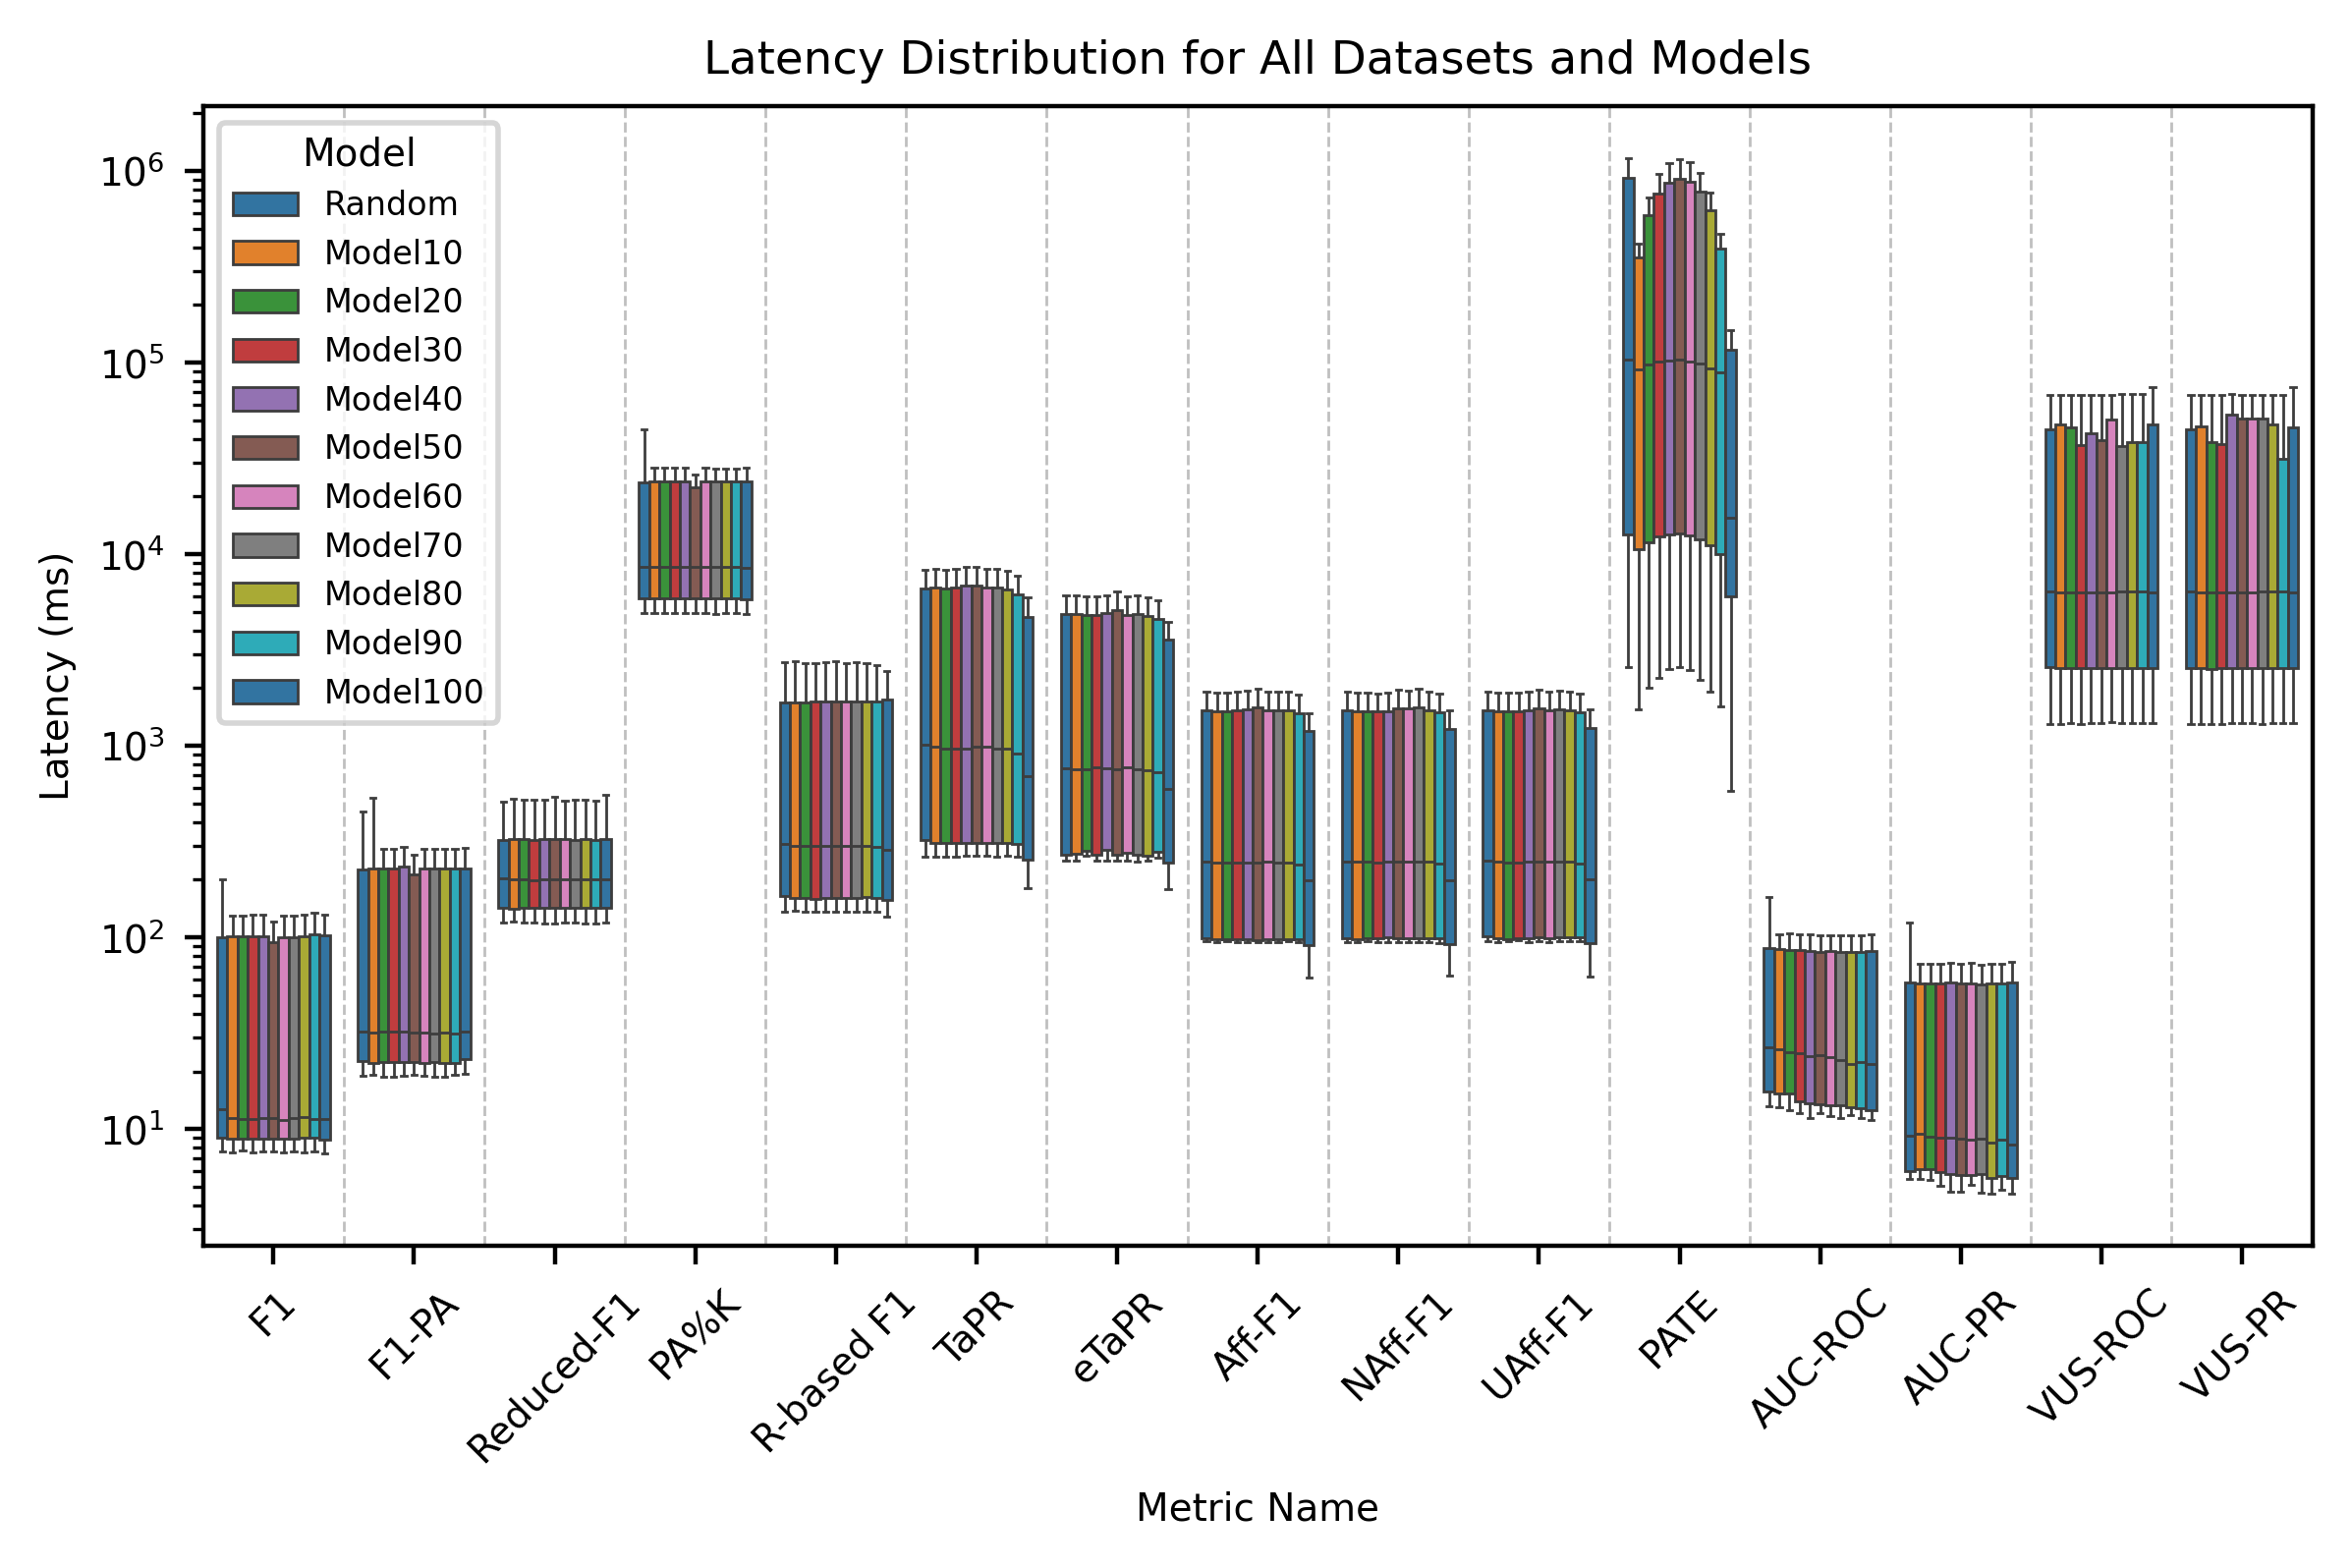

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_latency_distribution3(data_new):
    df = data_new.copy()

    # df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        if tmp.startswith('Model'):
            num_part = tmp.split('Model')[-1]
            return int(num_part)
        else:
            return -float('inf')
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
                  "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_latency'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    

    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

        
    plt.legend(title='Model', fontsize=6, loc='upper left', title_fontsize=7)
    # tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for All Datasets and Models')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_latency_real.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
# plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000